## Localization Pipeline

Run the end-to-end localization pipeline (data loading -> preprocessing -> localization -> post-processing). Save key outputs for later evaluation.


In [7]:
%load_ext autoreload
%autoreload 2

In [20]:
from pathlib import Path
import sys

# Add project root so src imports work when running from notebooks/.
sys.path.append(str(Path().resolve().parent))

from src.config import (
    PART1_KAGGLE_DIR,
    PART2_IMAGES_DIR,
    PART2_ANNOTATIONS_DIR,
    validate_data_layout,
    MODELS_DIR,
    OPTION_C_CNN,
    LOCALIZATION_DIR
)

validate_data_layout()

print("Data paths validated:")
print(f"- Part 1: {PART1_KAGGLE_DIR}")
print(f"- Part 2 Images: {PART2_IMAGES_DIR}")
print(f"- Part 2 Annotations: {PART2_ANNOTATIONS_DIR}")
print(f"- Model Directories: {MODELS_DIR}")

Data paths validated:
- Part 1: E:\Git\ecse415-final-project\data\part1\data\kaggle
- Part 2 Images: E:\Git\ecse415-final-project\data\part2\Stanford Dog Dataset\Images
- Part 2 Annotations: E:\Git\ecse415-final-project\data\part2\Stanford Dog Dataset\Annotation
- Model Directories: E:\Git\ecse415-final-project\outputs\models


### Imports & Device Setup

In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image

import cv2
import matplotlib.pyplot as plt

from src.config import (
    IMG_SIZE_CNN,
    CLASS_NAMES,
    FIGURES_DIR,
    MODELS_DIR,
    LOCALIZATION_DIR,
    OUTPUTS_DIR,

)
from src.utils import (
    load_labeled_images,
    split_data,
    get_pytorch_dataloaders,
    load_test_images,
    generate_submission_csv,
    build_gpu_augmentation,
)
from src.evaluation import compute_metrics, compute_confusion_matrix
from src.visualization import (
    plot_confusion_matrix,
    plot_training_history,
    plot_sample_predictions,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(f"Using device: {device}")

2.11.0+cu126
Using device: cuda


### Localization Strategy

Define the localization model based on the CNN defined in Part 1

Next, we take the model from Part1, and modify the final layer

In [63]:
class GradCAM_Locator:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        # Register the hooks to grab data during the forward and backward passes
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_ouput):
        self.gradients = grad_ouput[0]

    def get_bounding_box(self, image_tensor, original_image_shape, threshold=0.5):

        # Forward pass
        output = self.model(image_tensor)

        dog_class_index = 1
        score = output[:, dog_class_index]

        # Backward Pass to get gradients
        self.model.zero_grad()
        score.backward()

        # Calculate Grad-CAM Heatmap
        pooled_gradients = torch.mean(self.gradients.detach(), dim=[0,2,3])

        for i in range(self.activations.shape[1]):
            self.activations[:, i, :,:] *= pooled_gradients[i]

        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)

        max_val = torch.max(heatmap)
        if max_val > 0:
            heatmap /= max_val

        heatmap = heatmap.cpu().detach().numpy()
        heatmap_resized = cv2.resize(heatmap, (original_image_shape[1], original_image_shape[0]))

        # Apply binary threshold
        binary_map = (heatmap_resized > threshold).astype(np.uint8) * 255

        # Find contours
        contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None
    
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        return [x,y,w,h]

### Load models

In [65]:
model_path = MODELS_DIR / OPTION_C_CNN
# print(model_path)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = True
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2),
)
model.load_state_dict(torch.load(model_path, weights_only=True, map_location=device))
model.to(device)
model.eval()
# print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Hooks attached to: Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
<class 'torch.Tensor'>
Success! Dog localized at: x=115, y=92, width=252, height=168


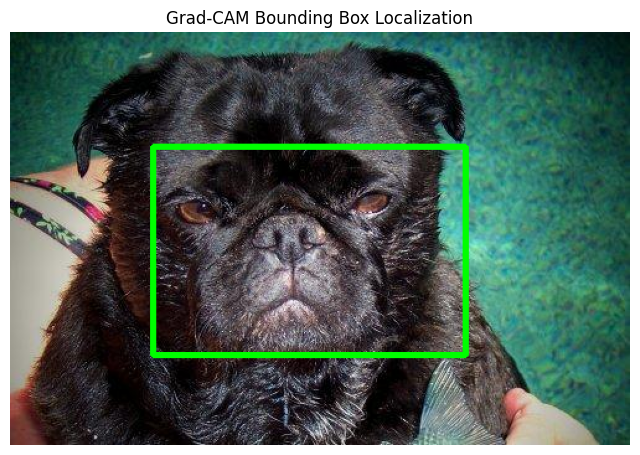

In [70]:
# 1. Attach the hooks to the final Conv2d layer in ResNet50's layer4
target_layer = model.layer4[2].conv3
cam_extractor = GradCAM_Locator(model, target_layer)
print(f"Hooks attached to: {target_layer}")

# 2. Setup a test image
test_image_path = PART2_IMAGES_DIR / 'n02110958-pug' / 'n02110958_25.jpg'

# Load image using OpenCV
original_image = cv2.imread(test_image_path)


original_shape = original_image.shape 

# 3. Standard ResNet preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pil_image = Image.fromarray(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
input_tensor = transform(pil_image).unsqueeze(0).to(device)
print(type(input_tensor))

# 4. Extract the Bounding Box
# Try adjusting the threshold between 0.3 and 0.7 if the box is too tight or too loose
bbox = cam_extractor.get_bounding_box(input_tensor, original_shape, threshold=0.3)

# 5. Visualize the Result
if bbox:
    x, y, w, h = bbox
    print(f"Success! Dog localized at: x={x}, y={y}, width={w}, height={h}")
    
    # Draw a thick green box on the image
    cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 4)
    
    # Convert BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Grad-CAM Bounding Box Localization")
    plt.show()
else:
    print("No dog localized above the activation threshold.")

In [ ]:
from tqdm import tqdm
import os

OUTPUT_JSON = "localization.json"
OUTPUT_JSON_PATH = LOCALIZATION_DIR / OUTPUT_JSON

all_image_paths = []
for breed_folder in os.listdir(PART2_IMAGES_DIR):
    breed_path = PART2_IMAGES_DIR / breed_folder
    if os.path.isdir(breed_path):
        for img_name in os.listdir(breed_path):
            if img_name.endswith(('.jpg')):
                all_image_paths.append(breed_path / img_name)

print(f"Found {len(all_image_paths)} images. Starting processing....")
